In [ ]:
!pip install pymongo[srv]

Found existing installation: pymongo 4.16.0
Uninstalling pymongo-4.16.0:
  Successfully uninstalled pymongo-4.16.0
Found existing installation: dnspython 2.8.0
Uninstalling dnspython-2.8.0:
  Successfully uninstalled dnspython-2.8.0
  Using cached pymongo-4.16.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (10.0 kB)
  Using cached dnspython-2.8.0-py3-none-any.whl.metadata (5.7 kB)
Using cached dnspython-2.8.0-py3-none-any.whl (331 kB)
Using cached pymongo-4.16.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.7 MB)


In [ ]:
from pymongo import MongoClient

uri = "mongodb+srv://<SEU_USUARIO_ATLAS>:<SUA_SENHA_ATLAS>@<SEU_CLUSTER_ATLAS>.mongodb.net/?retryWrites=true&w=majority"

client = MongoClient(uri)

try:
    client.admin.command("ping")
    print("Conectado com sucesso.")
except Exception as e:
    print("Erro:", e)

Conectado com sucesso.


In [ ]:
db = client["AulaDemo"]

In [ ]:
db.create_collection("Estudantes")

Collection(Database(MongoClient(host=['ac-p9lo5j5-shard-00-00.tgkhinl.mongodb.net:27017', 'ac-p9lo5j5-shard-00-02.tgkhinl.mongodb.net:27017', 'ac-p9lo5j5-shard-00-01.tgkhinl.mongodb.net:27017'], document_class=dict, tz_aware=False, connect=True, retrywrites=True, w='majority', authsource='admin', replicaset='atlas-pdfnx3-shard-0', tls=True), 'AulaDemo'), 'Estudantes')

In [ ]:
colecao = db["Estudantes"]

In [ ]:
colecao.insert_one({
    "nome": "Fernando Campos",
    "idade": 22,
    "curso": "Engenharia da Computação",
    "email": "fernando.campos@email.com"
})

InsertOneResult(ObjectId('69a6e28d61abe799d601ee3b'), acknowledged=True)

In [ ]:
colecao.insert_many([
    {
        "nome": "Mariano Rodrigues",
        "idade": 20,
        "curso": "Design Gráfico"
    },
    {
        "nome": "Roberta Lara",
        "idade": 23,
        "curso": "Ciência da Computação"
    }
])

InsertManyResult([ObjectId('69a6e29761abe799d601ee3c'), ObjectId('69a6e29761abe799d601ee3d')], acknowledged=True)

In [ ]:
for doc in colecao.find():
    print(doc)

{'_id': ObjectId('69a6e28d61abe799d601ee3b'), 'nome': 'Fernando Campos', 'idade': 22, 'curso': 'Engenharia da Computação', 'email': 'fernando.campos@email.com'}
{'_id': ObjectId('69a6e29761abe799d601ee3c'), 'nome': 'Mariano Rodrigues', 'idade': 20, 'curso': 'Design Gráfico'}
{'_id': ObjectId('69a6e29761abe799d601ee3d'), 'nome': 'Roberta Lara', 'idade': 23, 'curso': 'Ciência da Computação'}


In [ ]:
for doc in colecao.find({"curso": "Engenharia da Computação"}):
    print(doc)

{'_id': ObjectId('69a6e28d61abe799d601ee3b'), 'nome': 'Fernando Campos', 'idade': 22, 'curso': 'Engenharia da Computação', 'email': 'fernando.campos@email.com'}


In [ ]:
for doc in colecao.find().sort("nome", 1):
    print(doc)

{'_id': ObjectId('69a6e28d61abe799d601ee3b'), 'nome': 'Fernando Campos', 'idade': 22, 'curso': 'Engenharia da Computação', 'email': 'fernando.campos@email.com'}
{'_id': ObjectId('69a6e29761abe799d601ee3c'), 'nome': 'Mariano Rodrigues', 'idade': 20, 'curso': 'Design Gráfico'}
{'_id': ObjectId('69a6e29761abe799d601ee3d'), 'nome': 'Roberta Lara', 'idade': 23, 'curso': 'Ciência da Computação'}


In [ ]:
for doc in colecao.find().limit(4):
    print(doc)

{'_id': ObjectId('69a6e28d61abe799d601ee3b'), 'nome': 'Fernando Campos', 'idade': 22, 'curso': 'Engenharia da Computação', 'email': 'fernando.campos@email.com', 'status': 'Ativo'}
{'_id': ObjectId('69a6e29761abe799d601ee3c'), 'nome': 'Mariano Rodrigues', 'idade': 20, 'curso': 'Design Gráfico'}


In [ ]:
colecao.update_one(
    {"nome": "Fernando Campos"},
    {"$set": {"status": "Ativo"}}
)

UpdateResult({'n': 1, 'electionId': ObjectId('7fffffff000000000000014c'), 'opTime': {'ts': Timestamp(1772545345, 3), 't': 332}, 'nModified': 1, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1772545345, 3), 'signature': {'hash': b'vV\xdc\x82\xbb\x99}V\xa0\x01H\x86\xaf\xda\xe8\xb1\x07\xfd5\x08', 'keyId': 7552982448540221441}}, 'operationTime': Timestamp(1772545345, 3), 'updatedExisting': True}, acknowledged=True)

In [ ]:
colecao.delete_one({"nome": "Roberta Lara"})

DeleteResult({'n': 1, 'electionId': ObjectId('7fffffff000000000000014c'), 'opTime': {'ts': Timestamp(1772544741, 15), 't': 332}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1772544741, 15), 'signature': {'hash': b'\x80-\xfb\x84\x94L\xd8\x96D\x8bL\xa4\xcd96k\xcd\xbbz\xfd', 'keyId': 7552982448540221441}}, 'operationTime': Timestamp(1772544741, 15)}, acknowledged=True)

In [ ]:
colecao.create_index("nome")

'nome_1'

In [ ]:
pipeline = [
    {"$group": {"_id": "$curso", "total": {"$sum": 1}}},
    {"$sort": {"total": -1}}
]

for doc in colecao.aggregate(pipeline):
    print(doc)

{'_id': 'Engenharia da Computação', 'total': 1}
{'_id': 'Design Gráfico', 'total': 1}


In [ ]:
vendas = db["Vendas"]

vendas.insert_many([
    {"produto": "Notebook Gamer", "categoria": "Eletrônicos", "valor": 5200},
    {"produto": "iPhone 17 1TB Promax", "categoria": "Eletrônicos", "valor": 17000},
    {"produto": "Livros Diversos", "categoria": "Livraria", "valor": 100}
])

InsertManyResult([ObjectId('69a6e5e061abe799d601ee71'), ObjectId('69a6e5e061abe799d601ee72'), ObjectId('69a6e5e061abe799d601ee73')], acknowledged=True)

In [ ]:
pipeline = [
    {
        "$group": {
            "_id": "$categoria",
            "receitaTotal": {"$sum": "$valor"}
        }
    },
    {"$sort": {"receitaTotal": -1}}
]

for doc in vendas.aggregate(pipeline):
    print(doc)

{'_id': 'Eletrônicos', 'receitaTotal': 28300}
{'_id': 'Esportes', 'receitaTotal': 1550}
{'_id': 'Móveis', 'receitaTotal': 1150}
{'_id': 'Livraria', 'receitaTotal': 700}


In [ ]:
import pandas as pd

df = pd.DataFrame(list(colecao.find()))
df

,_id,nome,idade,curso,email,status
0,69a6e28d61abe799d601ee3b,Fernando Campos,22,Engenharia da Computação,fernando.campos@email.com,Ativo
1,69a6e29761abe799d601ee3c,Mariano Rodrigues,20,Design Gráfico,NaN,NaN


In [ ]:


db = client["AulaDemo"]
vendas = db["Vendas"]

vendas.insert_many([
    {"produto": "Laptop", "categoria": "Eletrônicos", "valor": 1500},
    {"produto": "Smartphone", "categoria": "Eletrônicos", "valor": 1800},
    {"produto": "Televisor", "categoria": "Eletrônicos", "valor": 1700},
    {"produto": "Tablet", "categoria": "Eletrônicos", "valor": 700},
    {"produto": "Livros", "categoria": "Livraria", "valor": 400},
    {"produto": "Cadeira", "categoria": "Móveis", "valor": 850},
    {"produto": "Mesa", "categoria": "Móveis", "valor": 800},
    {"produto": "Tênis", "categoria": "Esportes", "valor": 450},
    {"produto": "Bicicleta", "categoria": "Esportes", "valor": 2200}
])

InsertManyResult([ObjectId('69a6e61c61abe799d601ee74'), ObjectId('69a6e61c61abe799d601ee75'), ObjectId('69a6e61c61abe799d601ee76'), ObjectId('69a6e61c61abe799d601ee77'), ObjectId('69a6e61c61abe799d601ee78'), ObjectId('69a6e61c61abe799d601ee79'), ObjectId('69a6e61c61abe799d601ee7a'), ObjectId('69a6e61c61abe799d601ee7b'), ObjectId('69a6e61c61abe799d601ee7c')], acknowledged=True)

In [ ]:
pipeline = [
    {
        "$group": {
            "_id": "$categoria",
            "receitaTotal": {"$sum": "$valor"}
        }
    },
    {
        "$sort": {"receitaTotal": -1}
    }
]

resultado = list(vendas.aggregate(pipeline))
resultado

[{'_id': 'Eletrônicos', 'receitaTotal': 34000},
 {'_id': 'Esportes', 'receitaTotal': 4200},
 {'_id': 'Móveis', 'receitaTotal': 2800},
 {'_id': 'Livraria', 'receitaTotal': 1100}]

In [ ]:
import pandas as pd

df = pd.DataFrame(resultado)
df.columns = ["Categoria", "Receita Total"]

df

,Categoria,Receita Total
0,Eletrônicos,34000
1,Esportes,4200
2,Móveis,2800
3,Livraria,1100


<Figure size 640x480 with 0 Axes>

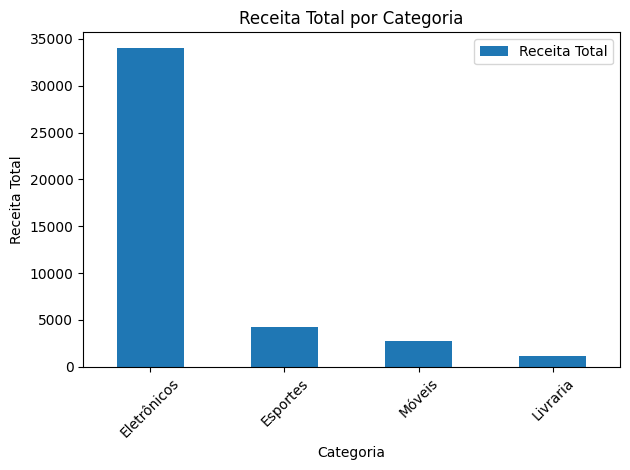

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df.plot(
    x="Categoria",
    y="Receita Total",
    kind="bar"
)

plt.title("Receita Total por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Receita Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()